# Methodology overview figure

Run the code cell below to generate **`docs/figures/methodology_overview.png`** and **`.pdf`** (matplotlib; no Mermaid).

## Layout (fixed structure)

1. **Two data sources** — PCam and CAMELYON17.
2. **One merged preprocessing** box — steps in parentheses (edit string in code).
3. **Four training arms** — Virchow2 on PCam, Virchow2 on CAMELYON17, CNN baseline on PCam, CNN baseline on CAMELYON17.
4. **Four evaluation boxes** — each arm scored on both datasets (in-domain test split + external transfer; wording mirrors the two directions).
5. **Metrics** — single merged box.
6. **Analysis** — single box (bootstrap / permutation / qualitative summaries as you prefer; edit text).

Edit the **`CONFIG`** dict in the code cell to change labels only; geometry is tuned for this layout.

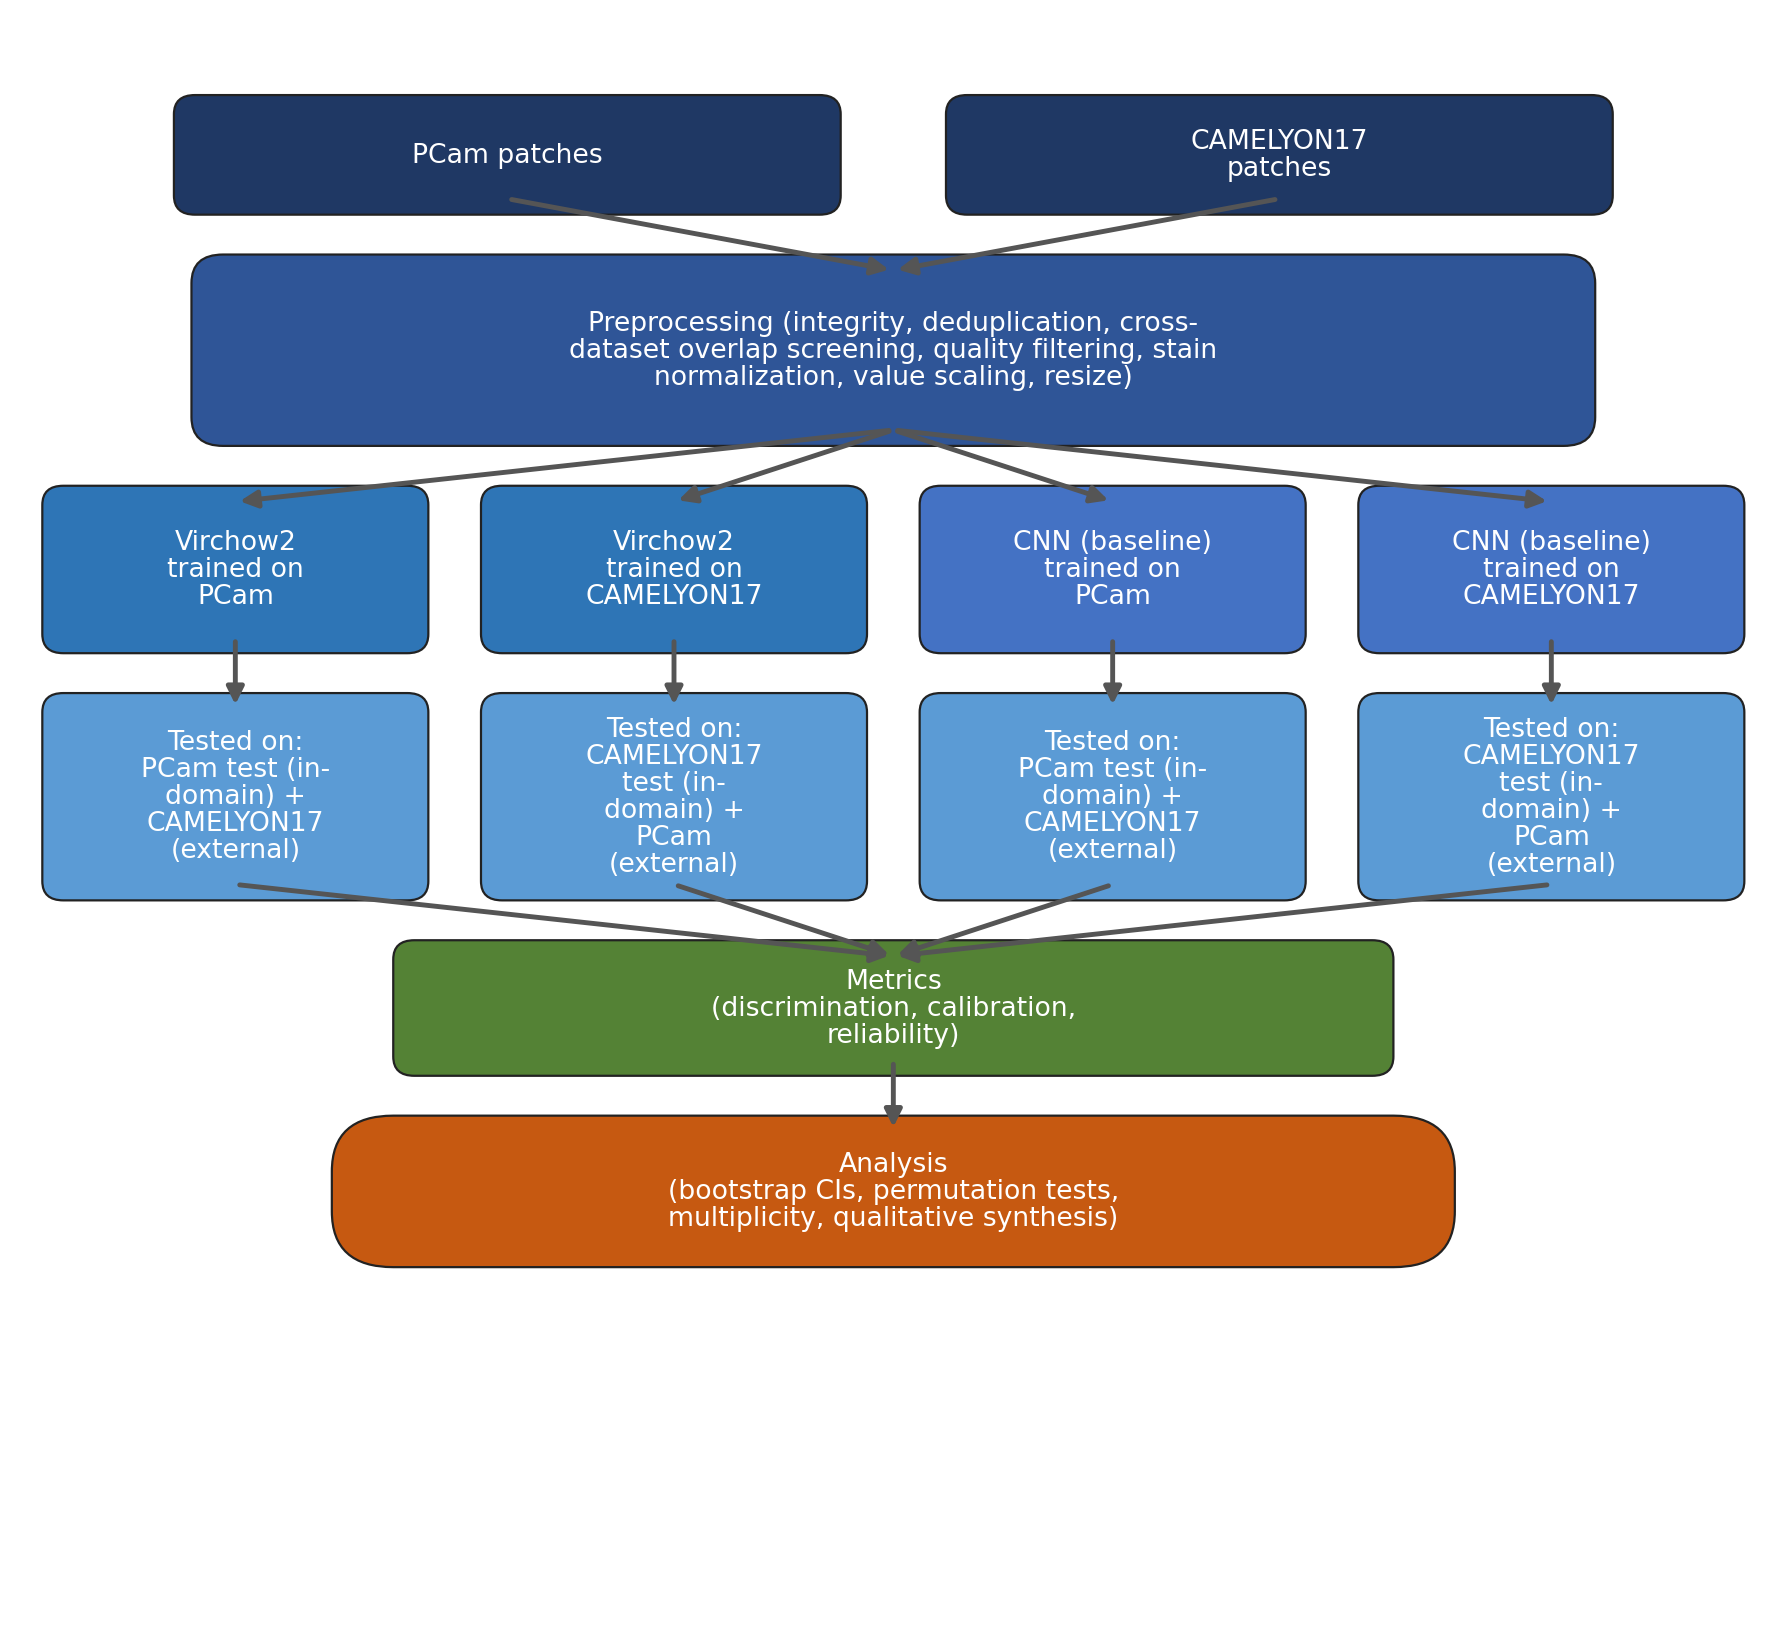

Wrote: C:\GP_ECG\docs\figures\methodology_overview.png
Wrote: C:\GP_ECG\docs\figures\methodology_overview.pdf


In [5]:
from __future__ import annotations

import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

CONFIG = {
    "data_left": "PCam patches",
    "data_right": "CAMELYON17 patches",
    "preprocess": (
        "Preprocessing "
        "(integrity, deduplication, cross-dataset overlap screening, "
        "quality filtering, stain normalization, value scaling, resize)"
    ),
    "train": [
        "Virchow2\ntrained on PCam",
        "Virchow2\ntrained on CAMELYON17",
        "CNN (baseline)\ntrained on PCam",
        "CNN (baseline)\ntrained on CAMELYON17",
    ],
    "eval": [
        "Tested on:\nPCam test (in-domain) +\nCAMELYON17 (external)",
        "Tested on:\nCAMELYON17 test (in-domain) +\nPCam (external)",
        "Tested on:\nPCam test (in-domain) +\nCAMELYON17 (external)",
        "Tested on:\nCAMELYON17 test (in-domain) +\nPCam (external)",
    ],
    "metrics": "Metrics\n(discrimination, calibration, reliability)",
    "analysis": "Analysis\n(bootstrap CIs, permutation tests, multiplicity, qualitative synthesis)",
}

_cwd = Path.cwd().resolve()
OUT_DIR = (_cwd / "docs" / "figures") if (_cwd / "docs").is_dir() else (_cwd.parent / "docs" / "figures")
OUT_PNG = OUT_DIR / "methodology_overview.png"
OUT_PDF = OUT_DIR / "methodology_overview.pdf"

FIG_W, FIG_H = 11.0, 10.0
DPI = 160
WRAP_DATA = 16
WRAP_PREP = 52
WRAP_SMALL = 14
WRAP_METRICS = 40
WRAP_ANALYSIS = 44

# Point size for all box labels (boxes stay same size; increase if still small)
FONT_BOX = 12
ARROW_LINEWIDTH = 2.2
ARROW_HEAD_SCALE = 16

COL_DATA = "#1f3864"
COL_PREP = "#2f5597"
COL_TRAIN_V = "#2e75b6"
COL_TRAIN_CNN = "#4472c4"
COL_EVAL = "#5b9bd5"
COL_METRICS = "#548235"
COL_ANALYSIS = "#c65911"
TEXT = "#ffffff"


def wrap(s: str, width: int) -> str:
    s = s.replace("\\n", "\n")
    parts = []
    for para in s.split("\n"):
        parts.extend(
            textwrap.wrap(
                para,
                width=width,
                break_long_words=False,
                replace_whitespace=False,
            )
            or [""]
        )
    return "\n".join(parts)


def rounded_box(ax, xy, w, h, text, facecolor, wrap_w, radius=0.012, fontsize=FONT_BOX):
    x, y = xy
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=f"round,pad=0.01,rounding_size={radius}",
        linewidth=1.0,
        edgecolor="#222222",
        facecolor=facecolor,
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        wrap(text, wrap_w),
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.05,
        color=TEXT,
        clip_on=False,
    )
    return (x + w / 2, y + h), (x + w / 2, y)  # top_center, bottom_center


def arrow(ax, p0, p1):
    ax.add_patch(
        FancyArrowPatch(
            p0,
            p1,
            arrowstyle="-|>",
            mutation_scale=ARROW_HEAD_SCALE,
            linewidth=ARROW_LINEWIDTH,
            color="#555555",
            shrinkA=2,
            shrinkB=2,
        )
    )


def draw():
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # --- Row 1: two data sources ---
    w_d, h_d = 0.36, 0.055
    cx_l, cx_r = 0.28, 0.72
    y1 = 0.94
    _, bc_l = rounded_box(
        ax,
        (cx_l - w_d / 2, y1 - h_d),
        w_d,
        h_d,
        CONFIG["data_left"],
        COL_DATA,
        WRAP_DATA,
    )
    _, bc_r = rounded_box(
        ax,
        (cx_r - w_d / 2, y1 - h_d),
        w_d,
        h_d,
        CONFIG["data_right"],
        COL_DATA,
        WRAP_DATA,
    )

    # --- Row 2: preprocessing (merge) ---
    gap = 0.045
    y2 = y1 - h_d - gap
    w_p, h_p = 0.78, 0.10
    cx = 0.5
    tc_p, bc_p = rounded_box(
        ax,
        (cx - w_p / 2, y2 - h_p),
        w_p,
        h_p,
        CONFIG["preprocess"],
        COL_PREP,
        WRAP_PREP,
        radius=0.018,
    )
    arrow(ax, bc_l, (cx, y2))
    arrow(ax, bc_r, (cx, y2))

    # --- Row 3: four training arms ---
    y3 = y2 - h_p - gap
    n = 4
    centers = [0.125, 0.375, 0.625, 0.875]
    w_t, h_t = 0.20, 0.085
    train_bottoms = []
    train_tops = []
    for i, cx_i in enumerate(centers):
        col = COL_TRAIN_V if i < 2 else COL_TRAIN_CNN
        tc, bc = rounded_box(
            ax,
            (cx_i - w_t / 2, y3 - h_t),
            w_t,
            h_t,
            CONFIG["train"][i],
            col,
            WRAP_SMALL,
        )
        train_tops.append(tc)
        train_bottoms.append(bc)
        arrow(ax, bc_p, tc)

    # --- Row 4: evaluation (per arm) ---
    y4 = y3 - h_t - gap
    w_e, h_e = 0.20, 0.11
    eval_bottoms = []
    eval_tops = []
    for i, cx_i in enumerate(centers):
        tc, bc = rounded_box(
            ax,
            (cx_i - w_e / 2, y4 - h_e),
            w_e,
            h_e,
            CONFIG["eval"][i],
            COL_EVAL,
            WRAP_SMALL,
        )
        eval_tops.append(tc)
        eval_bottoms.append(bc)
        arrow(ax, train_bottoms[i], tc)

    # --- Row 5: metrics (merge) ---
    y5 = y4 - h_e - gap
    w_m, h_m = 0.55, 0.065
    tc_m, bc_m = rounded_box(
        ax,
        (cx - w_m / 2, y5 - h_m),
        w_m,
        h_m,
        CONFIG["metrics"],
        COL_METRICS,
        WRAP_METRICS,
    )
    for eb in eval_bottoms:
        arrow(ax, eb, (cx, y5))

    # --- Row 6: analysis ---
    y6 = y5 - h_m - gap
    w_a, h_a = 0.62, 0.075
    _, _ = rounded_box(
        ax,
        (cx - w_a / 2, y6 - h_a),
        w_a,
        h_a,
        CONFIG["analysis"],
        COL_ANALYSIS,
        WRAP_ANALYSIS,
        radius=0.035,
    )
    arrow(ax, bc_m, (cx, y6))

    fig.tight_layout(pad=0.12)
    return fig


fig = draw()
OUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, bbox_inches="tight", facecolor="white")
fig.savefig(OUT_PDF, bbox_inches="tight", facecolor="white")
plt.show()
print("Wrote:", OUT_PNG.resolve())
print("Wrote:", OUT_PDF.resolve())